In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
two_levels_up = os.path.dirname(os.path.dirname(os.getcwd()))
parent_directory = two_levels_up#os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(os.path.dirname(os.getcwd()))

from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params
from detection_criteria import mag
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
from plot_hist import *
import pyarrow.dataset as ds
from filter_df import prepare_and_compute_metrics

Parent Directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


In [2]:
labelsparams = lambda p: labels[p]
label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'

label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}
CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
label_rmet_lat = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$", r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$", 
                 r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
label_rmet_lat = [r"$\frac{RB(\pi_E)_{Roman+Rubin}}{RB(\pi_E)_{Roman}}$", r"$\frac{SB(\pi_E)_{Roman+Rubin}}{SB(\pi_E)_{Roman}}$", 
                 r"$\frac{NU(\pi_E)_{Roman+Rubin}}{NU(\pi_E)_{Roman}}$"]
param_names = ['u0', 'tE', 'piE','piEE','piEN']
param_labels = [r'$\log_{10}(u_0)$', r'$t_E [day]$', r'$\log_{10}(\pi_E)$', r'$\log_{10}(|\pi_{EE}|)$',r'$\log_{10}(|\pi_{EN}|)$']

dict_cat_peak = {"A":"peak in Rubin+Roman",
                "B":"peak in Rubin",
                "C":"peak in Roman"}

In [3]:

model = 'FSPL'
system_type = "FFP"

if model=="PSPL":
    params = ["tE", "piE", "piEE", "piEN"]
elif model=="FSPL":
    params = ["tE", "piE","rho", "piEE", "piEN"]
    
from read_results_ import read_results
true, fit_roman, fit_rr, met_1_roman, met_1_rr, met_2_roman, met_2_rr, met_3_roman, met_3_rr, met1_ratio, met2_ratio, met3_ratio =read_results(system_type, model)


Parent Directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


This graph qualitatively shows that the parallax is best measured for longer-lasting events.

In [4]:
true_filtered = true

$\pi_E = \frac{AU}{D_\perp}(\frac{\Delta t_0}{t_E}, \Delta u_0)$

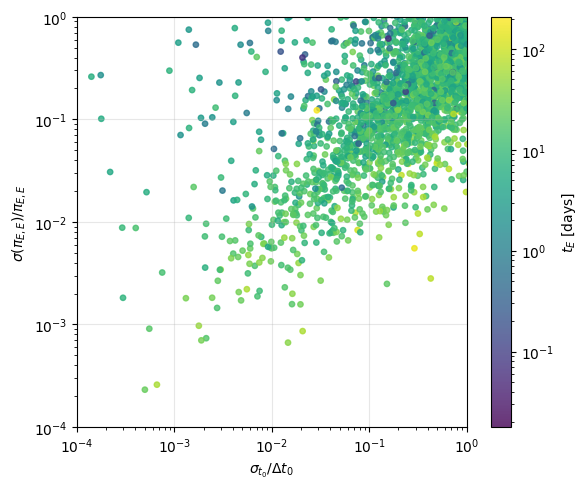

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from read_results_ import read_results

model = 'FSPL'
system_type = "FFP"

true, fit_roman, fit_rr, met_1_roman, met_1_rr, met_2_roman, met_2_rr, met_3_roman, met_3_rr, met1_ratio, met2_ratio, met3_ratio = read_results(system_type, model)

mets_list = [
    (met_1_rr, met_1_roman),
    (met_2_rr, met_2_roman),
    (met_3_rr, met_3_roman),
]

def add_delta_u0_t0(df):
    df = df.copy()
    df["delta_t0"] = df["piEE"] * df["tE"] * 0.01
    df["delta_u0"] = df["piEN"] * 0.01
    return df

fit_rr = add_delta_u0_t0(fit_rr)
true = add_delta_u0_t0(true)
fit_roman = add_delta_u0_t0(fit_roman)

cols = ['Source', 'Set']

# ------------------------------------------------------------
# Agregado nuevo:
# además de delta_t0_true, mergeo tE desde true para usarlo
# como color en el scatter
# ------------------------------------------------------------
df = fit_rr.merge(
    true[cols + ['delta_t0', 'tE']].rename(columns={
        'delta_t0': 'delta_t0_true',
        'tE': 'tE_true'
    }),
    on=cols,
    how='inner'
)

x = df['t0_err'] / df['delta_t0_true']
y = df['piEE_err'] / df['piEE']
c = df['tE_true']

mask = (
    np.isfinite(x) &
    np.isfinite(y) &
    np.isfinite(c) &
    (x > 0) &
    (y > 0) &
    (c > 0)
)

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    x[mask],
    y[mask],
    c=c[mask],
    norm=LogNorm(vmin=c[mask].min(), vmax=c[mask].max()),
    cmap='viridis',
    s=15,
    alpha=0.8
)

plt.xlabel(r'$\sigma_{t_0}/\Delta t_0$')
plt.ylabel(r'$\sigma(\pi_{E,E})/\pi_{E,E}$')
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3)

# en escala log no puede haber límite inferior 0
plt.xlim(1e-4, 1)
plt.ylim(1e-4, 1)

cbar = plt.colorbar(sc)
cbar.set_label(r'$t_E$ [days]')

plt.tight_layout()
plt.show()

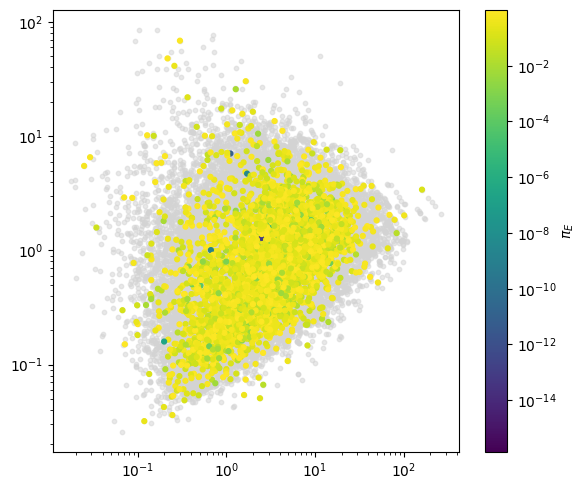

In [56]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

x = true["tE"]
y = true["piE"]
c = met_3_rr["piE"]

mask_all = (
    np.isfinite(x) &
    np.isfinite(y) &
    np.isfinite(c) &
    (x > 0) &
    (y > 0) &
    (c > 0)
)

mask_color = mask_all & (c < 1)

plt.figure(figsize=(6,5))

# --- puntos grises (todos)
plt.scatter(
    x[mask_all],
    y[mask_all],
    color="lightgray",
    s=10,
    alpha=0.5
)

# --- puntos coloreados (solo piE < 1)
sc = plt.scatter(
    x[mask_color],
    y[mask_color],
    c=c[mask_color],
    cmap="viridis",
    norm=LogNorm(vmin=c[mask_color].min(), vmax=c[mask_color].max()),
    s=12)

plt.xscale("log")
plt.yscale("log")
cbar = plt.colorbar(sc)
cbar.set_label(r'$\pi_E$')
plt.tight_layout()
plt.show()

In [6]:
events_bad_fit = []

for p in ['t0', 'u0', 'tE', 'piEE', 'piEN']:
    events_bad_fit.append(
        fit_roman[fit_roman[p + '_err'] == 0][["Source", "Set"]]
    )

# Unión de todos los dataframes, quitando duplicados
events_bad_fit = (
    pd.concat(events_bad_fit, ignore_index=True)
      .drop_duplicates()
      .reset_index(drop=True)
)

# events_bad_fit


In [7]:
# events_bad_fit contiene ["Source", "Set"] sin duplicados

events_good_fits = (
    fit_roman
    .merge(events_bad_fit, on=["Source", "Set"], how="left", indicator=True)
)

# Filtrar solo las filas que NO estén en events_bad_fit
events_good_fits = events_good_fits[events_good_fits["_merge"] == "left_only"]

# Eliminar columna auxiliar
events_good_fits = events_good_fits.drop(columns="_merge").reset_index(drop=True)
# events_good_fits

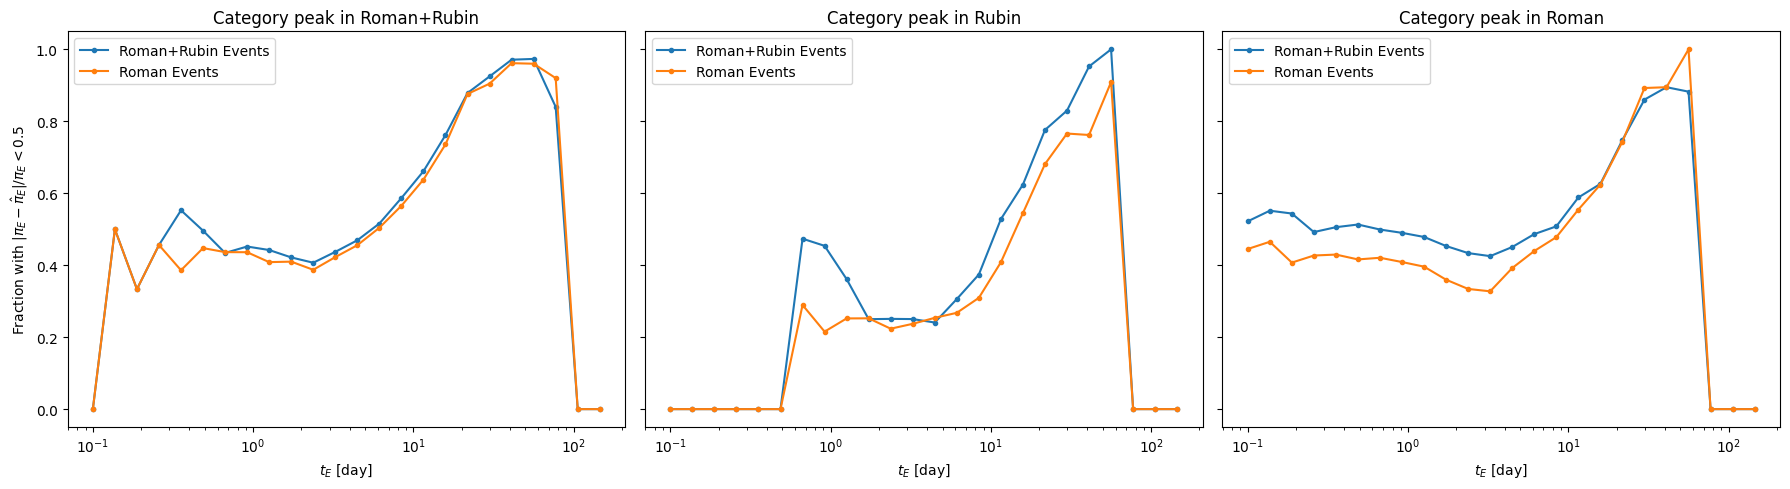

In [9]:
bins = np.logspace(-1, 2.3, 25)
x = bins[:-1]
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
# ------------------ Categoría A (pico en Roman+Rubin) ------------------
cat = 'A'
# numerador usando met_3_rr
true_filtered_rerror = true_filtered.merge(
    met_1_rr[met_1_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner')
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[0].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

# numerador usando met_3_roman
true_filtered_rerror = true_filtered.merge(
    met_1_roman[met_1_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[0].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')

axs[0].set_xscale('log')
axs[0].set_title('Category peak in Roman+Rubin')
axs[0].set_xlabel(r'$t_E$ [day]')
axs[0].set_ylabel('Fraction with $|\pi_E-\hat{\pi}_E|/\pi_E < 0.5$')
axs[0].legend()

# ------------------ Categoría B (pico en Rubin) ------------------
cat = 'B'
true_filtered_rerror = true_filtered.merge(
    met_1_rr[met_1_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[1].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

true_filtered_rerror = true_filtered.merge(
    met_1_roman[met_1_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[1].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')
axs[1].set_xscale('log')
axs[1].set_title('Category peak in Rubin')
axs[1].set_xlabel(r'$t_E$ [day]')
axs[1].legend()

# ------------------ Categoría C (pico en Roman) ------------------
cat = 'C'

true_filtered_rerror = true_filtered.merge(
    met_1_rr[met_1_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[2].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

true_filtered_rerror = true_filtered.merge(
    met_1_roman[met_1_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[2].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')

axs[2].set_xscale('log')
axs[2].set_title('Category peak in Roman')
axs[2].set_xlabel(r'$t_E$ [day]')
axs[2].legend()

plt.tight_layout()
plt.show()


In [12]:
for cat in ['A','B','C']:
    n_bot = (true_filtered['peak_flag'] == cat).sum()
    n_rr = (rr['peak_flag'] == cat).sum()
    n_rom = (rom['peak_flag'] == cat).sum()
    print(cat, "N_bot =", n_bot, "N_rr =", n_rr, "N_rom =", n_rom)

A N_bot = 18943 N_rr = 1489 N_rom = 1151
B N_bot = 6153 N_rr = 199 N_rom = 63
C N_bot = 38813 N_rr = 627 N_rom = 425


In [25]:
p = "rho" if ("rho" in true.columns) else "piE"
time = np.logspace(1,3,50)

all_ratios = []  # <- acumulador

for k, met in enumerate([[met_1_rr, met_1_roman],
                         [met_2_rr, met_2_roman],
                         [met_3_rr, met_3_roman]]):

    for cat in ["A","B","C"]:
        for t_tresh in range(len(time)-1):
            ti, tf = time[t_tresh], time[t_tresh+1]

            keys = true.loc[
                (true["peak_flag"]==cat) & (true["tE"]>ti) & (true["tE"]<tf),
                ["Source","Set"]
            ]
            m_rr    = met[0].merge(keys, on=["Source","Set"], how="inner").dropna(subset=[p]).set_index(["Source","Set"])
            m_roman = met[1].merge(keys, on=["Source","Set"], how="inner").dropna(subset=[p]).set_index(["Source","Set"])

            common = m_rr.index.intersection(m_roman.index)
            m_rr, m_roman = m_rr.loc[common].sort_index(), m_roman.loc[common].sort_index()

            # filtro en RR y re-sincronizo
            m_rr = m_rr[m_rr[p] < 0.5]
            if m_rr.empty:
                continue
            m_roman = m_roman.loc[m_rr.index]

            # construir df_ratio de ESTE bin/categoría y ACUMULAR
            df_ratio = (m_rr[p] / m_roman[p]).rename("ratio").reset_index()
            df_ratio["tE_min"] = ti
            df_ratio["tE_max"] = tf
            df_ratio["peak_flag"] = cat
            df_ratio["metric_id"] = k + 1  # opcional, por si querés saber qué métrica
            all_ratios.append(df_ratio)

# concatenar TODO al final
df_all = pd.concat(all_ratios, ignore_index=True)


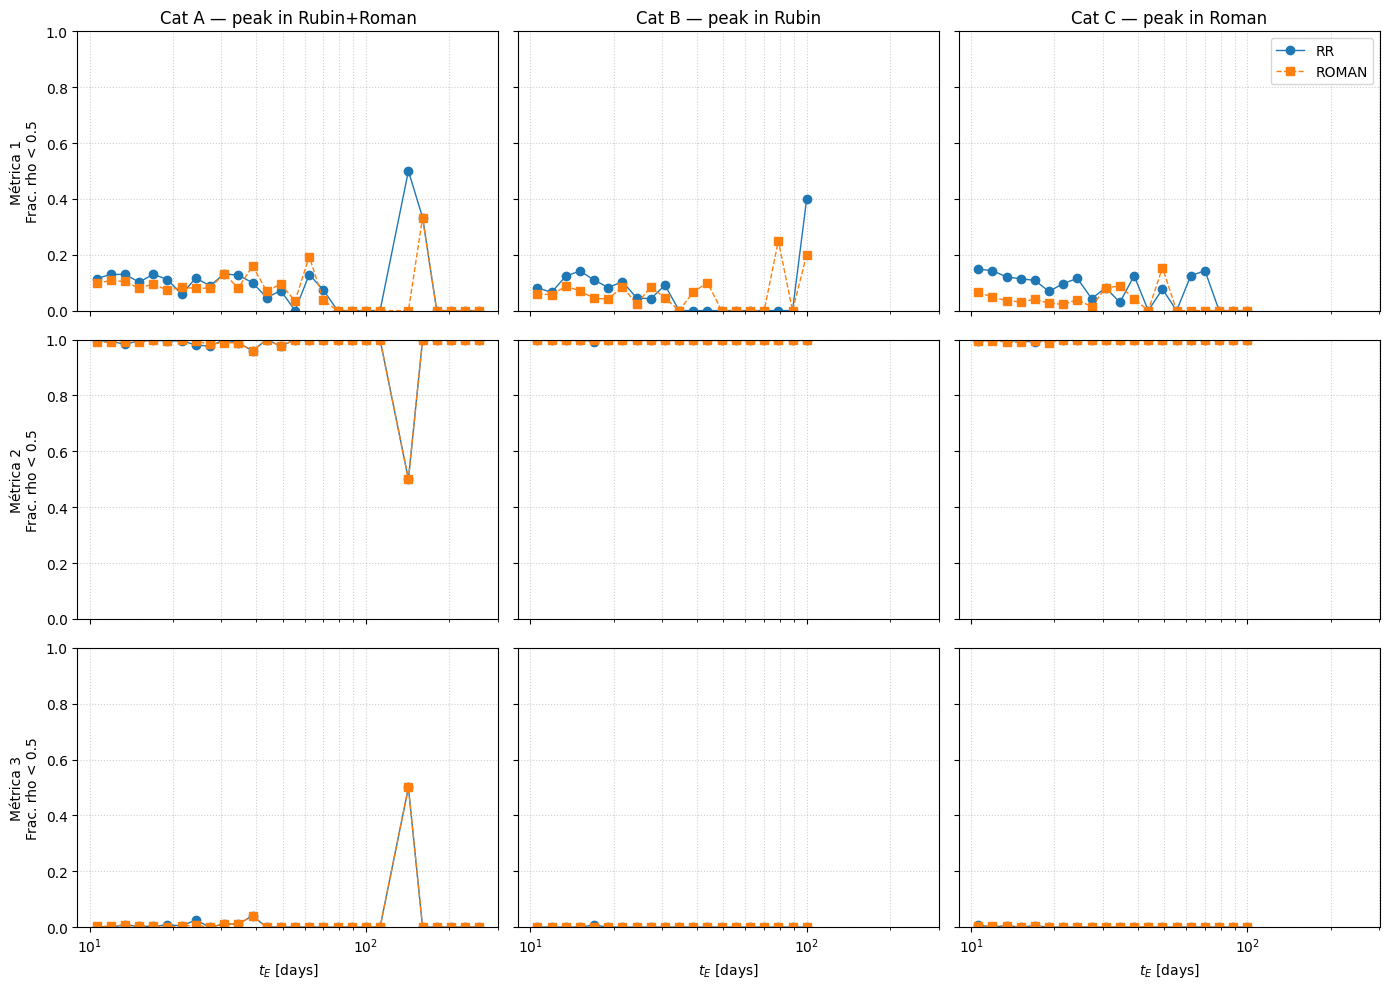

In [15]:

# =========================
# Configuración
# =========================
p = "rho" if ("rho" in true.columns) else "piE"
metric_threshold = 0.5
time_bins = np.logspace(1, 3, 40)  # bines de 10 a 1000 días
dict_cat_peak = globals().get("dict_cat_peak", {"A": "Cat A", "B": "Cat B", "C": "Cat C"})

metric_sets = [
    ("Métrica 1", (met_1_rr, met_1_roman)),
    ("Métrica 2", (met_2_rr, met_2_roman)),
    ("Métrica 3", (met_3_rr, met_3_roman)),
]
cats = ["A", "B", "C"]

# =========================
# Funciones auxiliares
# =========================
def fraction_per_bin(met_df, true_df, p, time_bins, threshold, cat):
    """Fracción por bin de tE para una categoría dada (A/B/C)."""
    x_centers, fracs = [], []
    for i in range(len(time_bins) - 1):
        ti, tf = time_bins[i], time_bins[i + 1]
        keys = true_df.loc[
            (true_df["peak_flag"] == cat) &
            (true_df["tE"] > ti) &
            (true_df["tE"] < tf),
            ["Source", "Set"]
        ]
        x_centers.append(np.sqrt(ti * tf))
        if keys.empty:
            fracs.append(np.nan)
            continue
        m = met_df.merge(keys, on=["Source", "Set"], how="inner").dropna(subset=[p])
        if len(m) == 0:
            fracs.append(np.nan)
        else:
            fracs.append((m[p] < threshold).mean())
    return np.array(x_centers), np.array(fracs)

# =========================
# Figura 3×3
# =========================
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

for r, (metric_name, (df_rr, df_ro)) in enumerate(metric_sets):
    for c, cat in enumerate(cats):
        ax = axes[r, c]

        # RR
        x_rr, y_rr = fraction_per_bin(df_rr, true, p, time_bins, metric_threshold, cat)
        m_rr = np.isfinite(y_rr)
        if m_rr.any():
            ax.plot(x_rr[m_rr], y_rr[m_rr], marker='o', linestyle='-', linewidth=1.0, label="RR")

        # ROMAN
        x_ro, y_ro = fraction_per_bin(df_ro, true, p, time_bins, metric_threshold, cat)
        m_ro = np.isfinite(y_ro)
        if m_ro.any():
            ax.plot(x_ro[m_ro], y_ro[m_ro], marker='s', linestyle='--', linewidth=1.0, label="ROMAN")

        ax.set_xscale("log")
        ax.set_ylim(0, 1)
        ax.grid(True, which='both', linestyle=':', alpha=0.6)

        # Títulos y etiquetas
        if r == 0:
            ax.set_title(f"Cat {cat} — {dict_cat_peak.get(cat, cat)}")
        if c == 0:
            ax.set_ylabel(f"{metric_name}\nFrac. {p} < {metric_threshold}")
        if r == len(metric_sets) - 1:
            ax.set_xlabel(r"$t_E$ [days]")

        # Leyenda solo en la esquina superior derecha para no recargar
        if r == 0 and c == 2:
            ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()


In [28]:
binsx = np.logspace(-3, 3, 30)
binsy = np.logspace(-0.5, 0.5, 30)

# Example usage
# fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'A'
p = 'piE'
x3 = met1_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
y3 = met3_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]

lab_piE = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$",r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
lab_rho = [r"$\frac{|\rho - \hat{\rho}|_{Roman+Rubin}}{|\rho - \hat{\rho}|_{Roman}}$",r"$\frac{\sigma_{\rho}/\hat{\rho}(Roman+Rubin)}{\sigma_{\rho}/\hat{\rho}(Roman)}$"]
# create_hist2d_with_marginals(axes, x3, y3, lab_piE, p,binsx,binsy)

# plt.show()

NameError: name 'met_1_rr_filtered' is not defined

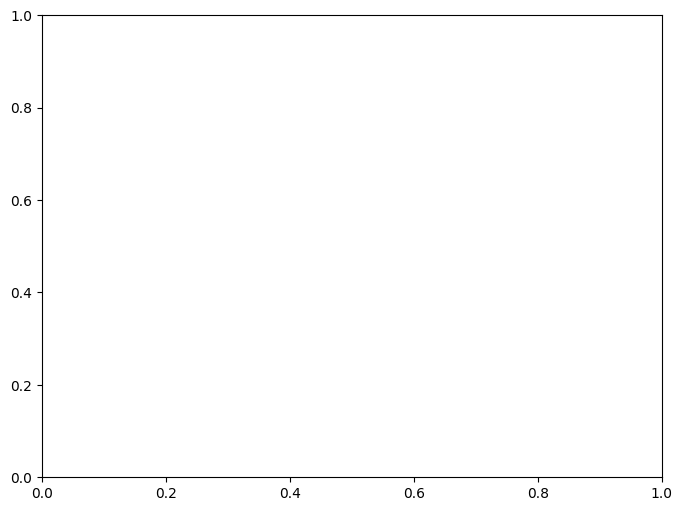

In [29]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)
cat, p = 'C', 'piE'
binsx = np.logspace(-6, 0.1, 30)
binsy = np.logspace(-5, 7, 30)
# p ='piE'

y = met1_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
x1 = met_1_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
x2 = met_1_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]

create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{|\pi_E - \hat{\pi}_E|}{\pi_E}$",r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$"], 'piE',binsx,binsy)

plt.show()

In [ ]:
# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'B'
binsx = np.logspace(-15, 5, 30)
binsy = np.logspace(-15, 5, 30)
y = met2_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x1 = met_2_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x2 = met_2_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
print(len(x1))

create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{|\pi_E - \hat{\pi}_E|}{\sigma(\pi_E)}$",r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$"], 'piE',binsx,binsy)

plt.show()

In [ ]:
# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'C'
binsx = np.logspace(-3, 3, 30)
binsy = np.logspace(-6, 1, 30)
y = met3_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x1 = met_3_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x2 = met_3_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
print(len(x1))
create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{\sigma(\hat{\pi}_E)}{\hat{\pi}_E}$",r"$\frac{\sigma(\hat{\pi}_E)/ \hat{\pi}_E (Roman+Rubin)}{\sigma(\hat{\pi}_E)/ \hat{\pi}_E (Roman)}$"], 'piE',binsx,binsy)

plt.show()

# Compute mass 

In [32]:
keys = ["Source", "Set"]
p= "piE"
s_rr    = met_2_rr.set_index(keys)[p]
s_roman = met_2_roman.set_index(keys)[p]
# Limitar al cruce de claves presentes en ambos DF
common = s_rr.index.intersection(s_roman.index)
mass_mask = (s_rr.loc[common] / s_roman.loc[common]) < 1
# mass_mask es un Series booleano indexado por (Source, Set)
# Si querés el mask en el orden de met_1_rr (incluyendo claves sin par en Roman):
mass_mask_rr_order = mass_mask.reindex(met_1_rr.set_index(keys).index)
keys = ["Source", "Set"]
# Asegurar que mass_mask tenga MultiIndex y esté bien alineada
mask = mass_mask.reindex(true.set_index(keys).index).fillna(False)
# Seleccionar las filas correspondientes
df_selected = true.loc[mask.values]
# df_selected
keys = ["Source", "Set"]
# Índices donde la condición es Fals
false_keys = mass_mask[~mass_mask].index
# Seleccionar en otro DataFrame (por coincidencia de claves)
df_not_selected = true.loc[
    true.set_index(keys).index.isin(false_keys)
]

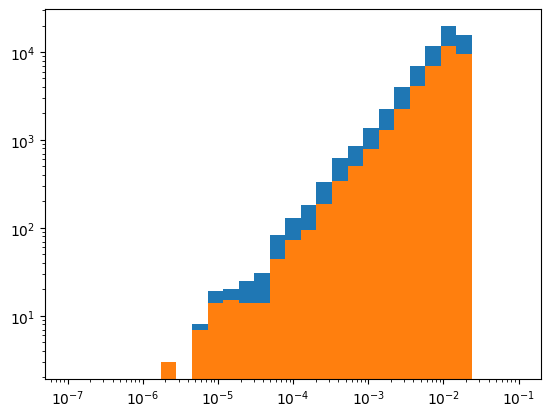

In [33]:
# plt.hist(plt.scatter(df_selected['mass'],df_selected['piE'],alpha=0.5)
plt.hist(true['mass'], bins=np.logspace(-7,-1,30))
plt.hist(df_not_selected['mass'], bins=np.logspace(-7,-1,30))#,df_not_selected['piE'],alpha=0.5))
plt.xscale("log")
plt.yscale("log")

In [ ]:
# Definir los mismos bins logarítmicos
bins = np.logspace(0, 2.1, 30)
# Calcular histogramas (sin dibujar todavía)
counts_true, edges = np.histogram(true["mass"], bins=bins)
counts_not, _     = np.histogram(df_not_selected["mass"], bins=bins)
# Evitar división por cero
ratio = np.divide(counts_not, counts_true, out=np.zeros_like(counts_true, dtype=float), where=counts_true>0)
# Calcular centro de cada bin
centers = (edges[:-1] + edges[1:]) / 2
# Graficar
plt.figure(figsize=(6,4))
plt.plot(centers, ratio, marker='o')
plt.xscale("log")
plt.yscale("linear")  # el cociente no suele necesitar escala log
plt.xlabel("Mass")
plt.ylabel(r"ratio  $RE(\pi_E)$")
plt.grid(True, which="both", ls=":")
plt.show()

In [ ]:
plt.scatter(df_selected['mass'],df_selected['piE'],alpha=0.5)
plt.scatter(df_not_selected['mass'],df_not_selected['piE'],alpha=0.5)
plt.xlabel(r'$M_L [M_{\odot}$]', fontsize=16)
plt.ylabel(r'$\pi_E $', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.show()

In [ ]:
plt.hist(met_1_rr['mass_v1'],np.logspace(-15,37,40),rwidth=0.9)
plt.hist(met_1_rr['mass_v2'],np.logspace(-15,37,40),histtype='step',linewidth=3)
if not model == "PSPL":
    plt.hist(met_1_rr['mass_v3'],np.logspace(-15,37,40),histtype='step',linewidth=3)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("RB(M)")
plt.show()

In [ ]:
tr